<a href="https://colab.research.google.com/github/polreig/StartUp_DecoAI/blob/main/Notebook_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalar el ecosistema

In [6]:
!pip install -q -U google-genai diffusers transformers accelerate opencv-python

## Importar librerías y cargar modelos

In [7]:
import torch
import cv2
import numpy as np
import json
import requests
from PIL import Image
from io import BytesIO
from pydantic import BaseModel
from typing import Tuple, Dict, Any

from google import genai
from google.genai import types
from google.colab import userdata
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

print("1. Cargando credenciales de Gemini...")
GOOGLE_API_KEY = userdata.get('clave_API_gemini')
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

print("2. Cargando ControlNet y Stable Diffusion a la GPU...")
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

print("¡Sistemas listos!")

1. Cargando credenciales de Gemini...
2. Cargando ControlNet y Stable Diffusion a la GPU...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


¡Sistemas listos!


## Función transformar habitación

In [8]:
# --- 1. ESQUEMA DE DATOS PARA GEMINI ---
class AnalisisDecoracion(BaseModel):
    estilo_actual: str
    recomendacion: str
    paleta_colores: list[str]
    prompt_sd: str
    muebles_clave: list[str]

# --- 2. FUNCIÓN DE IMAGEN INTELIGENTE ---
def preparar_imagen(ruta_o_url: str, max_size: int = 512) -> Image.Image:
    """Descarga y redimensiona la imagen manteniendo la proporción exacta."""
    try:
        if ruta_o_url.startswith('http'):
            response = requests.get(ruta_o_url, timeout=10)
            response.raise_for_status() # Falla si la URL está rota (ej. error 404)
            img = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            img = Image.open(ruta_o_url).convert("RGB")

        # Calcular proporciones para no aplastar los muebles
        ancho, alto = img.size
        if ancho > alto:
            nuevo_ancho = max_size
            nuevo_alto = int((alto / ancho) * max_size)
        else:
            nuevo_alto = max_size
            nuevo_ancho = int((ancho / alto) * max_size)

        # Stable Diffusion necesita que los píxeles sean múltiplos de 8
        nuevo_ancho = (nuevo_ancho // 8) * 8
        nuevo_alto = (nuevo_alto // 8) * 8

        return img.resize((nuevo_ancho, nuevo_alto), Image.Resampling.LANCZOS)
    except Exception as e:
        raise ValueError(f"Error al cargar la imagen. Revisa la URL o el archivo: {e}")

# --- 3. FUNCIÓN PRINCIPAL DE TRANSFORMACIÓN ---
def transformar_habitacion(ruta_o_url: str, peticion_usuario: str) -> Tuple[Dict[str, Any], Image.Image, Image.Image, Image.Image]:
    print("📥 Cargando y ajustando imagen original...")
    imagen_original = preparar_imagen(ruta_o_url)

    # FASE 1: ANÁLISIS ESTRUCTURADO CON GEMINI
    print("🧠 Analizando la habitación con Gemini (Modo JSON)...")
    prompt_gemini = f"""
    Eres un diseñador de interiores experto. El cliente pide: '{peticion_usuario}'.
    Analiza la foto y extrae los datos solicitados.
    El 'prompt_sd' debe ser una única frase en inglés, muy descriptiva,
    optimizada para Stable Diffusion (ej: 'modern living room, leather sofa, highly detailed, 8k').
    """

    try:
        respuesta_gemini = gemini_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[imagen_original, prompt_gemini],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=AnalisisDecoracion,
            )
        )
        # Convertimos la respuesta segura en un diccionario de Python
        datos_analisis = json.loads(respuesta_gemini.text)
    except Exception as e:
        raise RuntimeError(f"Error al conectar con Gemini: {e}")

    # FASE 2: EXTRACCIÓN DE ESTRUCTURA (Canny Edge)
    print("📐 Extrayendo plano de la habitación (ControlNet)...")
    imagen_cv = np.array(imagen_original)
    bordes = cv2.Canny(imagen_cv, 100, 200)
    imagen_bordes = Image.fromarray(np.stack([bordes, bordes, bordes], axis=2))

    # FASE 3: GENERACIÓN
    print("🎨 Dibujando el nuevo diseño...")
    prompt_negativo = "low quality, bad anatomy, worst quality, cartoon, illustration, distorted, messy, deformed furniture"

    imagen_generada = pipe(
        datos_analisis["prompt_sd"],
        negative_prompt=prompt_negativo,
        image=imagen_bordes,
        num_inference_steps=25
    ).images[0]

    return datos_analisis, imagen_original, imagen_bordes, imagen_generada

## Prueba

📥 Cargando y ajustando imagen original...
🧠 Analizando la habitación con Gemini (Modo JSON)...
📐 Extrayendo plano de la habitación (ControlNet)...
🎨 Dibujando el nuevo diseño...


  0%|          | 0/25 [00:00<?, ?it/s]


✨ ANÁLISIS DE TU HABITACIÓN ✨
- Estilo Actual: Minimalista con influencias nórdicas y Japandi
- Recomendación: Para transformar este espacio en un dormitorio de estilo industrial, se recomienda reemplazar la pared de lamas de madera por una de ladrillo visto. El marco de la cama de madera clara debe cambiarse por una estructura de metal negro o madera oscura y metal. Los textiles deben ser más oscuros y robustos. Se deben introducir elementos de iluminación y mobiliario con acabados de metal negro y detalles industriales, como lámparas tipo Edison o tuberías expuestas. La alfombra actual podría reemplazarse por una con textura más gruesa o de tonos grises y oscuros.
- Colores sugeridos: Gris carbón, Negro, Rojo ladrillo, Marrón óxido, Blanco roto

(Prompt enviado a la IA: An industrial style bedroom, with an exposed red brick wall behind a black metal platform bed, dark grey bedding, concrete floor, large window with dark metal framed panes, black metal minimalist clothes rack, indust

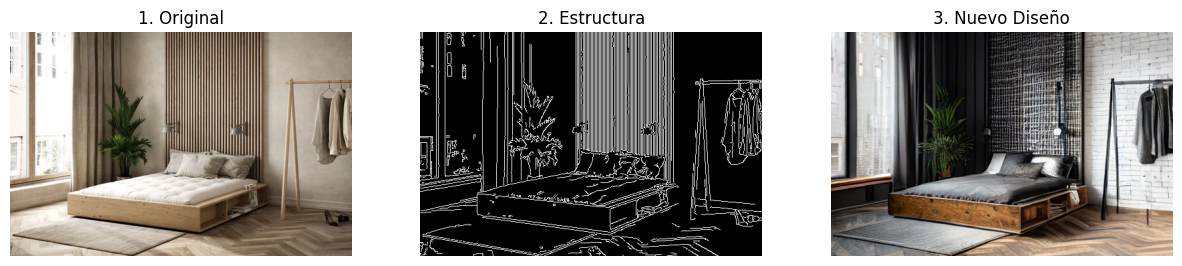

In [9]:
import matplotlib.pyplot as plt

mi_foto = "https://concept-u.es/cdn/shop/articles/habitacion-comoda.webp?v=1703692446"
mi_peticion = "Quiero convertir esto en una habitación de estilo industrial, con ladrillo visto y muebles de metal negro."

try:
    # Ejecutamos el nuevo pipeline
    datos, img_orig, img_bordes, img_final = transformar_habitacion(mi_foto, mi_peticion)

    # Mostramos el texto formateado desde el diccionario
    print("\n" + "="*50)
    print("✨ ANÁLISIS DE TU HABITACIÓN ✨")
    print(f"- Estilo Actual: {datos['estilo_actual']}")
    print(f"- Recomendación: {datos['recomendacion']}")
    print(f"- Colores sugeridos: {', '.join(datos['paleta_colores'])}")
    print("="*50 + "\n")
    print(f"(Prompt enviado a la IA: {datos['prompt_sd']})\n")

    # Mostramos las imágenes
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_orig); axes[0].set_title("1. Original"); axes[0].axis("off")
    axes[1].imshow(img_bordes); axes[1].set_title("2. Estructura"); axes[1].axis("off")
    axes[2].imshow(img_final); axes[2].set_title("3. Nuevo Diseño"); axes[2].axis("off")
    plt.show()

except Exception as e:
    print(f"❌ Vaya, ocurrió un error: {e}")

## Función generadora de links

In [10]:
import urllib.parse
from IPython.display import display, HTML

def generar_links_compra(lista_muebles: list[str]):
    print("🛒 Generando links de tus productos recomendados...")

    html_links = "<div style='background-color: #f0f4f8; padding: 20px; border-radius: 10px; font-family: sans-serif;'>"
    html_links += "<h3 style='margin-top: 0; color: #333;'>🛍️ Tu Lista de la Compra:</h3><ul style='list-style-type: none; padding-left: 0;'>"

    for mueble in lista_muebles:
        if not mueble: continue

        busqueda_codificada = urllib.parse.quote(mueble)
        link_ikea = f"https://www.ikea.com/es/es/search/?q={busqueda_codificada}"
        link_amazon = f"https://www.amazon.es/s?k={busqueda_codificada}"

        html_links += f"""
        <li style='margin-bottom: 15px; padding: 10px; background: white; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);'>
            <span style='font-size: 16px; font-weight: bold; color: #2c3e50;'>🛋️ {mueble.title()}</span><br>
            <div style='margin-top: 8px;'>
                <a href='{link_ikea}' target='_blank' style='display: inline-block; background-color: #0058a3; color: white; padding: 5px 10px; text-decoration: none; border-radius: 3px; font-size: 14px; margin-right: 10px;'>Busca en IKEA</a>
                <a href='{link_amazon}' target='_blank' style='display: inline-block; background-color: #ff9900; color: white; padding: 5px 10px; text-decoration: none; border-radius: 3px; font-size: 14px; color: #111;'>Busca en Amazon</a>
            </div>
        </li>
        """

    html_links += "</ul></div>"
    return html_links



## Probamos los links

In [12]:
# En Colab, display(HTML()) renderiza el código HTML como si fuera una web
display(HTML(generar_links_compra(datos['muebles_clave'])))

🛒 Generando links de tus productos recomendados...
